In [6]:
# data load
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

sys.path.append(os.path.abspath(".."))

from src.data_loading import load_raw_data

df = load_raw_data("../data/raw/raw_credit_applications.json")
df.shape

INFO | src.data_loading | Loaded 502 raw records from '../data/raw/raw_credit_applications.json'.
INFO | src.data_loading | Successfully flattened 502/502 records.


(502, 34)

### 1. Pre-processing
Before computing any group-level statistics, raw data quality issues that directly affect fairness metrics must be resolved. This includes normalising inconsistent gender encoding, parsing mixed date formats to derive applicant age, casting annual income to a numeric type, deduplicating records by application ID, and flagging invalid credit history values.

In [7]:
# normalise inconsistent gender encoding: 'M' -> 'Male', 'F' -> 'Female', blank -> NaN
gender_map = {"M": "Male", "F": "Female", "": pd.NA}
df["gender_clean"] = df["gender"].replace(gender_map)

print("Gender value counts after normalisation:")
print(df["gender_clean"].value_counts(dropna=False))

Gender value counts after normalisation:
gender_clean
Female    251
Male      248
NaN         3
Name: count, dtype: int64


In [8]:
# parse date_of_birth — three mixed formats present: YYYY-MM-DD, DD/MM/YYYY, YYYY/MM/DD
# format="mixed" handles all variants; errors="coerce" converts unparseable values to NaT
df["dob_parsed"] = pd.to_datetime(df["date_of_birth"], format="mixed", dayfirst=False, errors="coerce")
df["age"] = ((pd.Timestamp("today") - df["dob_parsed"]).dt.days // 365).astype("Int64")

print(f"Date parse failures (NaT): {df['dob_parsed'].isna().sum()}")
print(f"Age — min: {df['age'].min()}, max: {df['age'].max()}, nulls: {df['age'].isna().sum()}")

Date parse failures (NaT): 5
Age — min: 23, max: 67, nulls: 5


In [9]:
# cast annual_income to numeric (5 records store None as a Python object)
df["annual_income_num"] = pd.to_numeric(df["annual_income"], errors="coerce")

# deduplicate by application ID — keep first occurrence (2 duplicate IDs found in data quality audit)
df = df.drop_duplicates(subset="id", keep="first").reset_index(drop=True)

# flag negative credit_history_months as invalid (min=-10 found in data quality audit)
invalid_credit = (df["credit_history_months"] < 0).sum()
df.loc[df["credit_history_months"] < 0, "credit_history_months"] = pd.NA

print(f"Records after deduplication: {len(df)}")
print(f"Negative credit_history_months set to NaN: {invalid_credit}")

Records after deduplication: 500
Negative credit_history_months set to NaN: 2


In [10]:
'''
Pre-processing summary:
- Gender normalised to Male / Female / NaN (collapsed 'M', 'F', and blank variants)
- date_of_birth parsed with format="mixed"; age derived as integer years from today
- annual_income cast to numeric via pd.to_numeric(errors="coerce")
- 2 duplicate application IDs removed (app_001, app_042); 500 records remain
- 1 negative credit_history_months value set to NaN

All subsequent analyses use gender_clean, age, and annual_income_num.
The original columns (gender, date_of_birth, annual_income) are retained for reference.
'''

'\nPre-processing summary:\n- Gender normalised to Male / Female / NaN (collapsed \'M\', \'F\', and blank variants)\n- date_of_birth parsed with format="mixed"; age derived as integer years from today\n- annual_income cast to numeric via pd.to_numeric(errors="coerce")\n- 2 duplicate application IDs removed (app_001, app_042); 500 records remain\n- 1 negative credit_history_months value set to NaN\n\nAll subsequent analyses use gender_clean, age, and annual_income_num.\nThe original columns (gender, date_of_birth, annual_income) are retained for reference.\n'

### 2. Approval Rate Overview
Establishes the baseline approval rates across the full dataset and by gender group. These figures are the direct inputs to the Disparate Impact ratio computed in Section 3.

In [11]:
# overall approval rate
overall_rate = df["loan_approved"].mean()
print(f"Overall approval rate: {overall_rate:.1%}  ({df['loan_approved'].sum()}/{len(df)})")

# approval rate by gender
gender_rates = (
    df.groupby("gender_clean", observed=True)["loan_approved"]
    .agg(approved="sum", total="count", approval_rate="mean")
    .assign(approval_rate=lambda x: x["approval_rate"].round(4))
)
print("\nApproval rate by gender:")
display(gender_rates)

Overall approval rate: 58.4%  (292/500)

Approval rate by gender:


,approved,total,approval_rate
gender_clean,,,
Female,127,251,0.5060
Male,163,247,0.6599


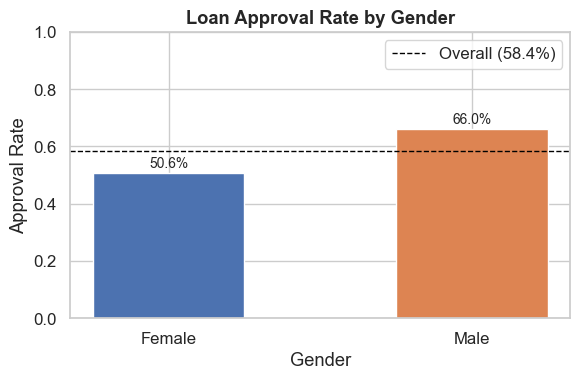

In [12]:
# bar chart: approval rate by gender
fig, ax = plt.subplots(figsize=(6, 4))

groups = gender_rates.index.tolist()
rates  = gender_rates["approval_rate"].tolist()
colors = ["#4C72B0", "#DD8452", "#55A868"]

bars = ax.bar(groups, rates, color=colors[:len(groups)], edgecolor="white", width=0.5)
ax.axhline(overall_rate, color="black", linestyle="--", linewidth=1,
           label=f"Overall ({overall_rate:.1%})")

ax.set_title("Loan Approval Rate by Gender", fontweight="bold")
ax.set_xlabel("Gender")
ax.set_ylabel("Approval Rate")
ax.set_ylim(0, 1)
ax.legend()

for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{rate:.1%}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig("../reports/figures/02_approval_rate_by_gender.png", dpi=150)
plt.show()